In [21]:
import os
from pathlib import Path

from matplotlib import pyplot as plt
import numpy as np
import seaborn as sn
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

from helper_code import *

In [2]:
%load_ext autoreload

%autoreload 2

# Control figure size
figsize=(14, 4)

---

In [204]:
hdf5_files = [file for file in os.listdir("code15_hdf5") if file.endswith(".hdf5")]
exams = pd.read_csv("code15_hdf5/exams.csv")
exams_sliced = exams[exams["trace_file"].isin(hdf5_files)]

In [205]:
exams_sliced.head()

,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file
352,3158243,59,False,64.235565,False,False,False,False,False,False,1280570,NaN,NaN,False,exams_part0.hdf5
353,1126697,63,False,67.575520,False,False,False,False,False,False,223781,False,2.17808,True,exams_part0.hdf5
354,91288,49,False,55.587772,False,False,False,False,False,False,1546425,NaN,NaN,False,exams_part0.hdf5
355,2660251,42,False,48.175446,False,False,False,False,False,False,160919,False,7.24383,False,exams_part0.hdf5
356,4390974,42,True,47.617800,False,False,False,False,False,False,98649,NaN,NaN,False,exams_part0.hdf5


In [206]:
# Check NaN values in the DataFrame
exams_sliced.isna().sum()

exam_id                 0
age                     0
is_male                 0
nn_predicted_age        0
1dAVb                   0
RBBB                    0
LBBB                    0
SB                      0
ST                      0
AF                      0
patient_id              0
death               11684
timey               11684
normal_ecg              0
trace_file              0
dtype: int64

In [207]:
# Filter out rows with NaN in the 'death' column from the exams DataFrame
filtered_exams = exams.dropna(subset=['death'])

# Merge exams_sliced with the filtered exams on 'patient_id'
exams_sliced = exams_sliced.merge(
    filtered_exams[['patient_id', 'death']],
    on='patient_id',
    how='left',
    suffixes=('', '_new')
)

# Fill NaN values in the original 'death' column with the updated 'death_new' values
exams_sliced['death'] = exams_sliced['death'].combine_first(exams_sliced['death_new'])

# Drop the temporary 'death_new' column
exams_sliced = exams_sliced.drop(columns=['death_new'])

In [208]:
# Check NaN values in the DataFrame
exams_sliced.isna().sum()

exam_id                 0
age                     0
is_male                 0
nn_predicted_age        0
1dAVb                   0
RBBB                    0
LBBB                    0
SB                      0
ST                      0
AF                      0
patient_id              0
death                  10
timey               11684
normal_ecg              0
trace_file              0
dtype: int64

In [209]:
# Filter out rows with NaN in the 'death' column from the exams DataFrame
filtered_times = exams.dropna(subset=['timey'])

# Merge exams_sliced with the filtered exams on 'patient_id'
exams_sliced = exams_sliced.merge(
    filtered_times[['patient_id', 'timey']],
    on='patient_id',
    how='left',
    suffixes=('', '_new')
)

# Fill NaN values in the original 'death' column with the updated 'death_new' values
exams_sliced['timey'] = exams_sliced['timey'].combine_first(exams_sliced['timey_new'])

# Drop the temporary 'death_new' column
exams_sliced = exams_sliced.drop(columns=['timey_new'])

In [212]:
# Check NaN values in the DataFrame
exams_sliced.isna().sum()

exam_id              0
age                  0
is_male              0
nn_predicted_age     0
1dAVb                0
RBBB                 0
LBBB                 0
SB                   0
ST                   0
AF                   0
patient_id           0
death               10
timey               10
normal_ecg           0
trace_file           0
dtype: int64

In [211]:
print("Number of patients:", exams_sliced.patient_id.nunique())
print("Number of records:", exams_sliced.exam_id.nunique())

Number of patients: 37658
Number of records: 40000


In [213]:
exams_sliced.dropna(inplace=True)

In [214]:
exams_sliced.describe()

,exam_id,age,nn_predicted_age,patient_id,timey
count,3.999000e+04,39990.000000,39990.000000,3.999000e+04,39990.000000
mean,1.460571e+06,52.998025,53.904460,7.918334e+05,4.055776
std,1.158793e+06,19.724134,18.642235,5.523368e+05,1.803814
min,1.400000e+01,17.000000,-12.739881,4.000000e+00,0.000000
25%,5.678812e+05,36.000000,37.285012,2.482170e+05,2.581505
50%,1.133210e+06,54.000000,55.082463,7.570925e+05,3.917805
75%,2.658110e+06,70.000000,69.592703,1.281853e+06,5.764379
max,4.416554e+06,91.000000,100.572266,1.773653e+06,7.676706


In [215]:
exams_sliced.isna().sum()

exam_id             0
age                 0
is_male             0
nn_predicted_age    0
1dAVb               0
RBBB                0
LBBB                0
SB                  0
ST                  0
AF                  0
patient_id          0
death               0
timey               0
normal_ecg          0
trace_file          0
dtype: int64

In [216]:
exams_sliced['health_qual'] = exams_sliced['age'] - exams_sliced['nn_predicted_age']

In [217]:
exams_sliced.drop(columns=['patient_id', 'nn_predicted_age'], inplace=True)

In [219]:
exams_sliced = pd.get_dummies(exams_sliced, columns=['is_male'])

In [220]:
def get_records(data_path: Path) -> list:
    """
    Get all records from a given data path
    """
    records = find_records(data_path.absolute())
    return [int(record) for record in records]

In [221]:
train_data_folder = Path("code15_wfdb")
holdout_data_folder = Path("holdout_data")

records = get_records(train_data_folder)
holdout_records = get_records(holdout_data_folder)

records.extend(holdout_records)

In [105]:
#classes = {'0': 0, '1': 0}
#
#for i, record in enumerate(records):
#    label = load_label(str(train_data_folder) + "/" + record)
#    classes[str(label)] += 1
#
#record = str(train_data_folder) + "/" + records[0]
#header = load_header(record)
#print(header)
#age = get_age(header)
#wfdb.plot_wfdb(record=wfdb.rdrecord(record, physical=False))
#signal, fields = load_signals(record)
#signal
#load_label(record)

In [223]:
def get_record_and_label(exam_id: int, records: list[int]) -> int:
    try:
        record_idx = records.index(exam_id)
    except ValueError:
        return -1

    try:
        str_record = str(train_data_folder.absolute()) + "/" + str(records[record_idx])
        label = load_label(str_record)
    except FileNotFoundError:
        str_record = str(holdout_data_folder.absolute()) + "/" + str(records[record_idx])
        label = load_label(str_record)

    signal, fields = load_signals(str_record)
    mean_signal = np.mean(signal, axis=0)
    std_signal = np.std(signal, axis=0)

    result = {}
    num_signals = signal.shape[1]
    signal_names = fields['sig_name']
    for i in range(num_signals):
        signal_name = signal_names[i]
        result[f"mean_{signal_name}"] = mean_signal[i]
        result[f"std_{signal_name}"] = std_signal[i]
    result['chagas'] = label

    return result # 0 -> no Chagas, 1 -> Chagas

In [224]:
signal_df = exams_sliced.apply(lambda x: get_record_and_label(x['exam_id'], records), axis=1, result_type='expand')

In [225]:
exams_all = pd.concat([exams_sliced, signal_df], axis=1)

In [226]:
exams_all[exams_all['chagas'] != -1.0]

,exam_id,age,1dAVb,RBBB,LBBB,SB,ST,AF,death,timey,...,std_V2,mean_V3,std_V3,mean_V4,std_V4,mean_V5,std_V5,mean_V6,std_V6,chagas
0,3158243,59,False,False,False,False,False,False,False,7.180816,...,0.400598,0.000151,0.456922,0.000520,0.393117,0.001221,0.360301,0.001675,0.304419,0.0
1,1126697,63,False,False,False,False,False,False,False,2.178080,...,0.219475,0.003491,0.385895,0.012380,0.321636,0.008122,0.299980,0.000402,0.238634,0.0
2,91288,49,False,False,False,False,False,False,False,4.490407,...,0.948528,-0.517819,0.865806,0.393827,0.835939,-0.618210,0.588355,-1.554662,0.371574,0.0
3,2660251,42,False,False,False,False,False,False,False,7.243830,...,0.287649,-0.007196,0.389992,-0.010232,0.504824,-0.002026,0.496042,-0.002731,0.384833,0.0
4,4390974,42,False,False,False,False,False,False,False,5.016434,...,1.052599,-1.391919,1.008797,-2.901048,0.799211,-6.178393,1.053436,-3.765900,1.845213,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,1660678,76,False,False,False,False,False,False,False,2.843833,...,0.205438,0.000641,0.412974,-0.003489,0.488760,-0.002175,0.355661,0.000001,0.236229,0.0
39996,343570,55,False,False,False,False,False,False,False,3.882189,...,0.446441,1.393939,0.391673,0.816377,0.375468,-1.216566,0.463233,-0.685920,0.298793,0.0
39997,2974923,64,False,False,False,False,False,False,False,6.394515,...,0.419508,-1.033134,0.506864,0.140010,0.322220,0.200650,0.306546,0.012167,0.284587,0.0
39998,3784595,24,False,False,False,False,False,False,False,5.358900,...,0.305270,0.012960,0.652313,0.019818,0.442820,0.018507,0.343412,0.028188,0.249698,0.0


In [227]:
exams_all['death'].value_counts()

death
False    38317
True      1673
Name: count, dtype: int64

In [228]:
num_cols = [c for c in exams_all.columns[:-1] if exams_all[c].nunique() > 2]
cat_cols = [c for c in exams_all.columns[:-1] if exams_all[c].nunique() == 2]
print(f'Numeric: {num_cols}')
print(f'Categorical: {cat_cols}')

Numeric: ['exam_id', 'age', 'timey', 'health_qual', 'mean_I', 'std_I', 'mean_II', 'std_II', 'mean_III', 'std_III', 'mean_AVR', 'std_AVR', 'mean_AVL', 'std_AVL', 'mean_AVF', 'std_AVF', 'mean_V1', 'std_V1', 'mean_V2', 'std_V2', 'mean_V3', 'std_V3', 'mean_V4', 'std_V4', 'mean_V5', 'std_V5', 'mean_V6', 'std_V6']
Categorical: ['1dAVb', 'RBBB', 'LBBB', 'SB', 'ST', 'AF', 'death', 'normal_ecg', 'trace_file', 'is_male_False', 'is_male_True']


ValueError: hist method requires numerical or datetime columns, nothing to plot.

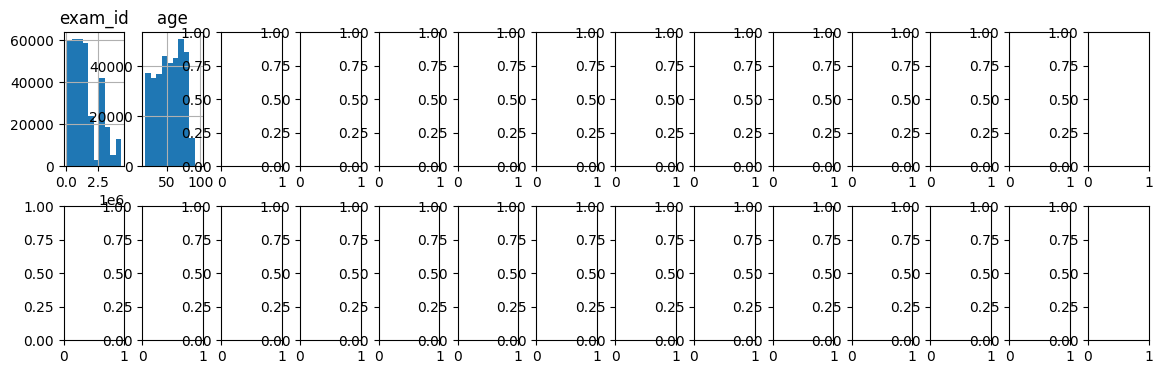

In [160]:
_, axes = plt.subplots(nrows=2, ncols=int(np.ceil(len(num_cols)//2)), figsize=figsize)
for ax, cname in zip(axes.ravel(), num_cols):
    exams.hist(cname, ax=ax)
plt.tight_layout()

In [ ]:
exams_sliced = exams_sliced.astype({
    'age': np.uint8,
    'nn_predicted_age': np.float32,
    'exam_id': 'category',
    'patient_id': 'category',
    'death': 'bool'
})